<a href="https://colab.research.google.com/github/siva123h/NNDL/blob/main/Implement_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
X_train shape: (25000, 200)
X_test shape : (25000, 200)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 119ms/step - accuracy: 0.7667 - loss: 0.4682 - val_accuracy: 0.8464 - val_loss: 0.3573
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.8972 - loss: 0.2620 - val_accuracy: 0.8770 - val_loss: 0.3036
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.9303 - loss: 0.1850 - val_accuracy: 0.8708 - val_loss: 0.3322
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 118ms/step - accuracy: 0.9478 - loss: 0.1426 - val_accuracy: 0.8640 - val_loss: 0.3496
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 118ms/step - accuracy: 0.9598 - loss: 0.1118 - val_accuracy: 0.8724 - val_loss: 0.4294

Test Accuracy: 85.97%
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
Negative (score: 0.21) → This movie was absolutely amazing!
Negative (score: 0.02) → Terrible film. Worst thing I ever watched.
Positive (score: 0.61) → It was okay, not great but not bad.


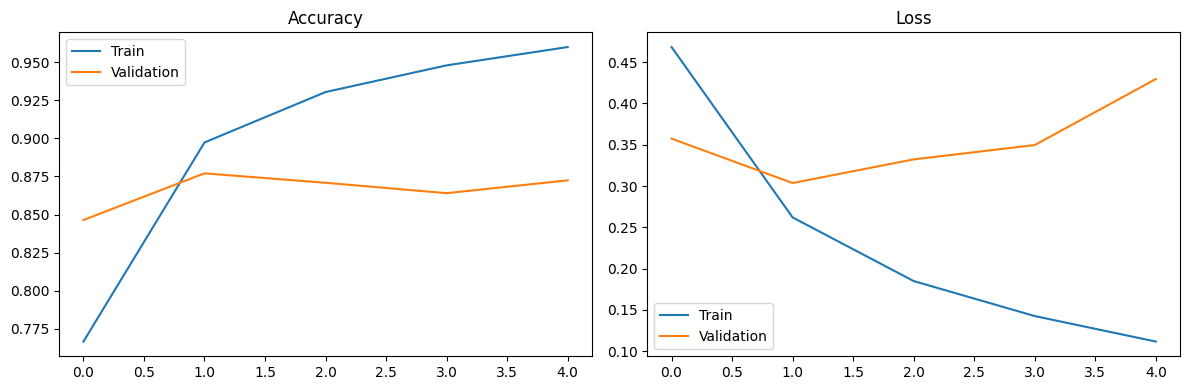

In [10]:
# Step 1: Install & Imports
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import matplotlib.pyplot as plt


# Step 2: Load Data
VOCAB_SIZE = 10000
MAX_LEN = 200

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

X_train = pad_sequences(X_train, maxlen=MAX_LEN)
X_test = pad_sequences(X_test, maxlen=MAX_LEN)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)


# Step 3: Build Model
model = Sequential([
    Embedding(VOCAB_SIZE, 64),
    LSTM(64, dropout=0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


# Step 4: Train
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


# Step 5: Evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {acc*100:.2f}%")


# Step 6: Predict on Your Own Text
word_index = imdb.get_word_index()

def predict(text):
    words = text.lower().split()
    tokens = [word_index.get(w, 2) + 3 for w in words]
    tokens = [t if t < VOCAB_SIZE else 2 for t in tokens]
    padded = pad_sequences([tokens], maxlen=MAX_LEN)

    score = model.predict(padded, verbose=0)[0][0]
    label = "Positive" if score > 0.5 else "Negative"

    print(f"{label} (score: {score:.2f}) → {text}")


# Test Predictions
predict("This movie was absolutely amazing!")
predict("Terrible film. Worst thing I ever watched.")
predict("It was okay, not great but not bad.")


# Step 7: Plot Results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()